<a href="https://colab.research.google.com/github/varunsahu5002/VDUI_ASSIGNMENT_2_UNIT2/blob/main/unit2_ppt7_activity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Unit 2 — Advanced Visualization & Storytelling (UE24CS342AA9)
## Activity Notebook: The Pre-Publish Ethics Review

### Scenario

You're a junior analyst at **Northwind Retail Insights**. A colleague drafted a set of
charts for tomorrow's regional performance report, and your manager asked you to review
them before they go out. She's blunt about what she wants checked:

1. *"I can't tell what I'm supposed to look at first on any of these charts. There's no
   hierarchy."*
2. *"One of these charts will get someone using a grayscale office printer completely
   lost. Fix that before it ships."*
3. *"I saw a headline chart that made a tiny year-over-year change look like a crisis.
   Check the axis."*
4. *"Someone wrote 'this PROVES our new strategy is working' under a chart. That's not
   what a data label is for."*

You'll work through the same review a real analyst would: fix a hierarchy problem, make
a chart accessible, catch a scale exaggeration, and rewrite an overreaching annotation.

Cells marked **`# TODO`** are for you to complete. Markdown cells marked **Reflection**
are for you to answer in your own words.

## Part 0 — Setup (given)

Run this cell as-is. It loads the real sales data you'll be working with.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

np.random.seed(0)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

sales = pd.read_csv("superstore.csv", encoding="latin-1")
sales["Order Date"] = pd.to_datetime(sales["Order Date"])
sales["Year"] = sales["Order Date"].dt.year

print(f"Loaded {len(sales):,} orders, {sales.Year.min()}-{sales.Year.max()}.")
sales[["Order Date", "Region", "Product Category", "Sales", "Profit"]].head()

Loaded 8,399 orders, 2009-2012.


,Order Date,Region,Product Category,Sales,Profit
0,2010-10-13,Nunavut,Office Supplies,261.5400,-213.25
1,2012-10-01,Nunavut,Office Supplies,10123.0200,457.81
2,2012-10-01,Nunavut,Office Supplies,244.5700,46.71
3,2011-07-10,Nunavut,Technology,4965.7595,1198.97
4,2010-08-28,Nunavut,Office Supplies,394.2700,30.94


## Task 1 — Fix the Missing Hierarchy (Complaint #1)

**Real-world usage:** The manager can't tell what to look at first on the current
chart.

**Why this technique:** Visual hierarchy (size + weight + color) creates an
unmistakable primary -> secondary -> tertiary reading order without needing
instructions.

**TODO:** Build a figure with 3 text elements, using ONLY `fontsize`, `fontweight`, and
`color` to create hierarchy:
1. **Primary:** the region with the highest total profit, in large bold colored text.
2. **Secondary:** one supporting sentence, medium size, muted color.
3. **Tertiary:** a data-source footnote, small, light gray.

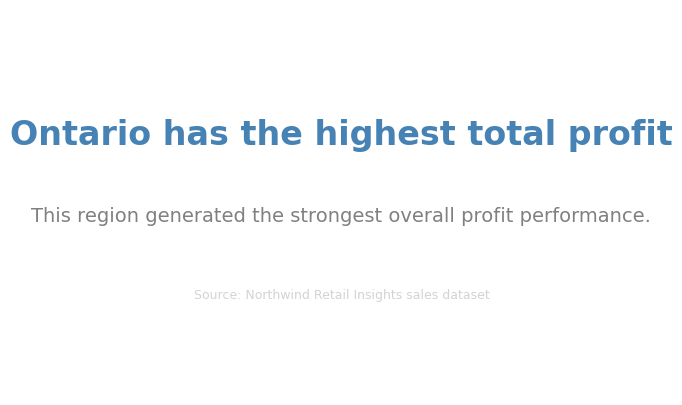

In [3]:
region_totals = sales.groupby("Region")["Profit"].sum().sort_values()

best_region = region_totals.idxmax()

fig, ax = plt.subplots(figsize=(7, 5))
ax.axis("off")

# TODO 1
ax.text(
    0.5, 0.65,
    f"{best_region} has the highest total profit",
    ha="center",
    fontsize=24,
    fontweight="bold",
    color="steelblue"
)

# TODO 2
ax.text(
    0.5, 0.45,
    "This region generated the strongest overall profit performance.",
    ha="center",
    fontsize=14,
    color="gray"
)

# TODO 3
ax.text(
    0.5, 0.25,
    "Source: Northwind Retail Insights sales dataset",
    ha="center",
    fontsize=9,
    color="lightgray"
)

plt.show()

**Reflection:** Without reading any labels, in what order do your eyes land on the
three text elements? If someone glanced at this for only 2 seconds, what's the one
fact they'd walk away with?

_Your answer:_

My eyes should land first on the large bold colored region name, then on the supporting sentence, and finally on the small source footnote. After a two-second glance, the main fact I would take away is which region generated the highest total profit.

## Task 2 — Make the Chart Accessible (Complaint #2)

**Real-world usage:** A colorblind or grayscale-printer viewer needs to be able to read
this chart too.

**Why this technique:** Redundant coding (color + pattern/shape) survives both
colorblindness and grayscale printing; color alone does not.

**TODO:**
1. Build a bar chart of total `Sales` by `Product Category`, one color per category.
2. Add a DIFFERENT hatch pattern per bar (`hatch="//"`, `"xx"`, `".."`) on top of the
   color, so the categories stay distinguishable if color is stripped away.
3. Add a legend showing category name.

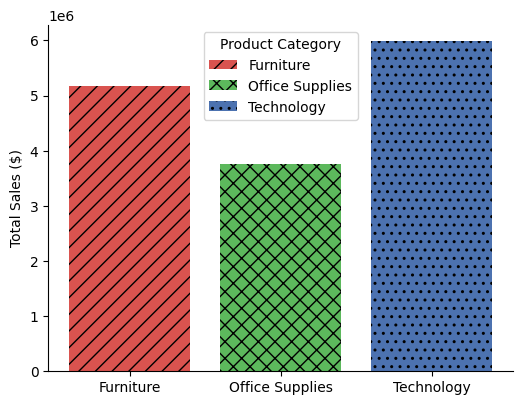

In [4]:
cat_sales = sales.groupby("Product Category")["Sales"].sum()

# TODO 1 & 2
colors = {
    "Furniture": "#D9534F",
    "Office Supplies": "#5cb85c",
    "Technology": "#4C72B0"
}

hatches = {
    "Furniture": "//",
    "Office Supplies": "xx",
    "Technology": ".."
}

fig, ax = plt.subplots(figsize=(6, 4.5))

for cat in cat_sales.index:
    ax.bar(
        cat,
        cat_sales[cat],
        color=colors[cat],
        hatch=hatches[cat],
        label=cat
    )

# TODO 3
ax.legend(title="Product Category")

ax.set_ylabel("Total Sales ($)")
plt.show()

**Reflection:** If you only used color (no hatch pattern), which two accessibility
failure modes from the lecture would this chart hit? Name both.

_Your answer:_

Using only color would create problems for colorblind viewers and for people viewing the chart in grayscale. These are the two accessibility failure modes because the categories could become difficult or impossible to distinguish when color differences are not visible.

## Task 3 — Catch the Axis Exaggeration (Complaint #3)

**Real-world usage:** A headline chart made a small real change look like a crisis.

**Why this technique:** Comparing the SAME data on a zero-baseline axis vs. a truncated
axis reveals exactly how much an axis choice is doing the "storytelling" instead of the
data.

**TODO:**
1. Compute total `Sales` by `Year`.
2. Compute the real percent change between the two most recent years.
3. Plot BOTH a zero-baseline version and a truncated-axis version, side by side, each
   titled with the real percent change.

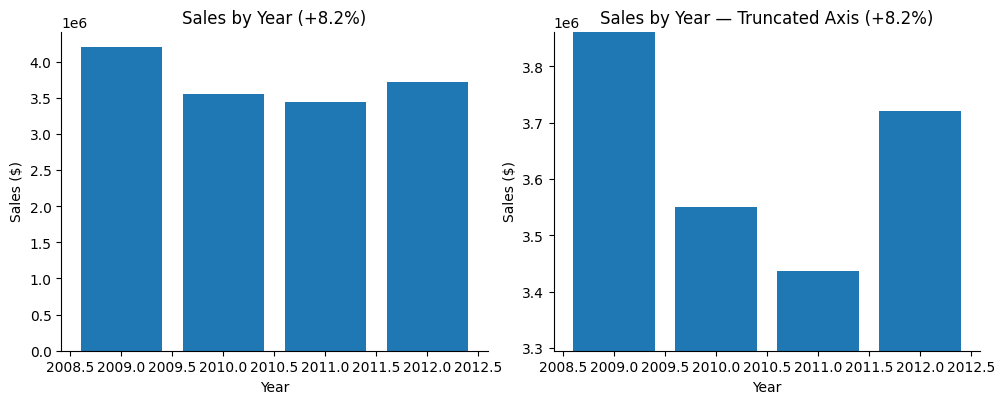

Real change from 2011 to 2012: +8.2%


In [5]:
yearly_sales = sales.groupby("Year")["Sales"].sum()

# TODO 1 & 2
y1, y2 = yearly_sales.index[-2], yearly_sales.index[-1]
v1, v2 = yearly_sales.iloc[-2], yearly_sales.iloc[-1]

pct_change = ((v2 - v1) / v1) * 100

fig, axes = plt.subplots(1, 2, figsize=(10, 4.3))

# TODO 3a
axes[0].bar(yearly_sales.index, yearly_sales.values)
axes[0].set_title(f"Sales by Year ({pct_change:+.1f}%)")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Sales ($)")
axes[0].set_ylim(bottom=0)

# TODO 3b
axes[1].bar(yearly_sales.index, yearly_sales.values)
axes[1].set_title(f"Sales by Year — Truncated Axis ({pct_change:+.1f}%)")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Sales ($)")

margin = (max(v1, v2) - min(v1, v2)) * 0.5
axes[1].set_ylim(
    min(v1, v2) - margin,
    max(v1, v2) + margin
)

plt.tight_layout()
plt.show()

print(f"Real change from {y1} to {y2}: {pct_change:+.1f}%")

**Reflection:** Which of your two panels would you flag for the manager as
potentially misleading if it were used ALONE as the report's headline chart, with no
other context? Why?

_Your answer:_

I would flag the truncated-axis panel as potentially misleading if it were used alone because starting the y-axis near the two values can make a relatively small percentage change look much larger than it actually is. The zero-baseline chart gives a more honest visual comparison of the magnitude of the change.

## Task 4 — Rewrite the Overreaching Annotation (Complaint #4)

**Real-world usage:** A colleague's annotation claimed a chart "PROVES" a strategy is
working — language the data alone cannot support.

**Why this technique:** Distinguishing descriptive / interpretive / persuasive
annotation lets you keep useful interpretation while cutting unsupported claims.

**TODO:**
1. Given the overreaching annotation text below, write a DESCRIPTIVE version (states
   only the fact) and an INTERPRETIVE version (explains a plausible, appropriately
   hedged reason) — no causal "PROVES" language in either.
2. Plot the yearly sales trend with your INTERPRETIVE annotation on the most recent
   data point.

In [ ]:
overreaching_original = "This PROVES our new strategy is working -- scale it up immediately"

# TODO 1
descriptive_version = "Sales increased in the most recent year compared with the previous year."

interpretive_version = "The increase in sales may indicate that the new strategy is contributing to improved performance, although other factors may also be involved."

print("ORIGINAL (persuasive, overreaching):", overreaching_original)
print("DESCRIPTIVE:", descriptive_version)
print("INTERPRETIVE:", interpretive_version)

# TODO 2
fig, ax = plt.subplots(figsize=(7, 4.3))

ax.plot(
    yearly_sales.index,
    yearly_sales.values,
    "o-",
    color="#4C72B0"
)

ax.annotate(
    interpretive_version,
    xy=(yearly_sales.index[-1], yearly_sales.values[-1]),
    xytext=(-120, 30),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->")
)

ax.set_title("Yearly Sales Trend")
ax.set_xlabel("Year")
ax.set_ylabel("Sales ($)")

plt.tight_layout()
plt.show()

**Reflection:** What specific evidence would you need (that this dataset alone
doesn't provide) before the ORIGINAL "proves it's working" claim would actually be
justified?

_Your answer:_

I would need evidence such as a controlled comparison with a period or group where the strategy was not used, while accounting for other factors that could affect sales. I would also want evidence showing that the improvement is consistently associated with the strategy rather than being caused by seasonality, market changes, or other business factors.

## Task 5 — The Decision (No Code)

**Reflection (final):** Write a 4–6 sentence sign-off note to your manager

summarizing
this review. Your answer should:
- State which ONE of the four fixes above you consider the most urgent to ship before
  tomorrow, and why.
- Reference the lecture's 5-question Ethical Visualization Audit — pick one question
  from it and explain how it applies to Task 3 or Task 4 specifically.
- Name one guardrail (a review step, a style-guide rule, etc.) you'd recommend
  permanently adding to the team's process to prevent these four issues recurring.

_Your final recommendation here:_

The most urgent fix to ship before tomorrow is correcting the truncated y-axis in Task 3, because it can make a small year-over-year change appear much larger than it really is. One question from the Ethical Visualization Audit is, “Could the visual design mislead the viewer?” and this applies directly to Task 3 because the truncated axis exaggerates the apparent size of the change. I would also review the annotation from Task 4 to ensure it describes the evidence without claiming that the strategy is proven to work. As a permanent guardrail, I would add a mandatory pre-publication review checklist covering axis baselines, accessibility, visual hierarchy, and whether annotations distinguish facts from interpretations.